In [1]:
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import distill.taskflow as taskflow
from pathlib import Path
from distill.configuration_file import config

c:\Users\roman\miniconda3\envs\geoloc2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
opt=config(r"distill/new_example_config.json")

In [4]:
from distill.taskflow import *


In [5]:
import torch

In [6]:
model = taskflow.FPI(opt, device="cpu")

In [7]:
ckpt = torch.load("checkpoints/test/output/net_001.pth", map_location="cpu")

C:\Users\roman\AppData\Local\Temp\ipykernel_24628\2364737467.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("checkpoints/test/output/net_001.pth", map

In [ ]:
model_keys = set(model.state_dict().keys())
ckpt = torch.load("checkpoints/test/output/net_001.pth", map_location="cpu")
new_state_dict = {}
for k, v in ckpt.items():
    # вариант без префикса
    if k in model_keys:
        new_state_dict[k] = v
    # вариант с префиксом
    elif "backbone_uav.backbone." + k in model_keys:
        new_state_dict["backbone_uav.backbone." + k] = v
    else:
        print("SKIP:", k)

missing, unexpected = model.load_state_dict(new_state_dict, strict=True)

print("missing:", missing)
print("unexpected:", unexpected)

missing: []
unexpected: []


In [ ]:
print(list(ckpt.keys())[:10])
print(list(model.state_dict().keys())[:10])

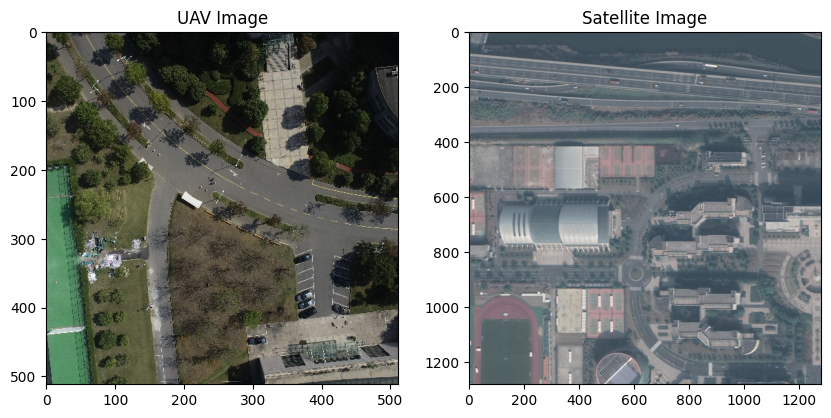

In [19]:
# For demonstration, load sample images
# Replace with actual paths to UAV and satellite images
uav_image_path = r'map2019\train\Caijing_000000\UAV\0.JPG'  # Example path
satellite_image_path = r'map2019\train\Caijing_000000\Satellite\0.tif'  # Example path

# Load images
uav_image = Image.open(uav_image_path)
satellite_image = Image.open(satellite_image_path)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(uav_image)
plt.title('UAV Image')
plt.subplot(1, 2, 2)
plt.imshow(satellite_image)
plt.title('Satellite Image')
plt.show()

In [ ]:
import json
import os


In [27]:
satellite_path=r'map2019\val\Chuanmei_100_000004\Satellite\0.jpg'

In [31]:
read_gps = json.load(
    open(
        os.path.join(
            satellite_path.split(r"\Satellite")[0],
            "GPS_info.json"),
        'r', encoding="utf-8"))

In [34]:
Path(satellite_path.split(r"\Satellite")[0]).joinpath("GPS_info.json")

WindowsPath('map2019/val/Chuanmei_100_000004/GPS_info.json')